In [6]:
from Bse_Explicit.bse_explicit_call_put_numba import bse_exp_call_numba
from Bse_Explicit.bse_analytical import bse_analytical
import scipy as sp
import numpy as np
from matplotlib import pyplot as plt
import time
from Bse_Explicit.bse_explicit_call_put import bse_exp_call
from Bse_Explicit.plots import gpu_main

4.6212047545501775


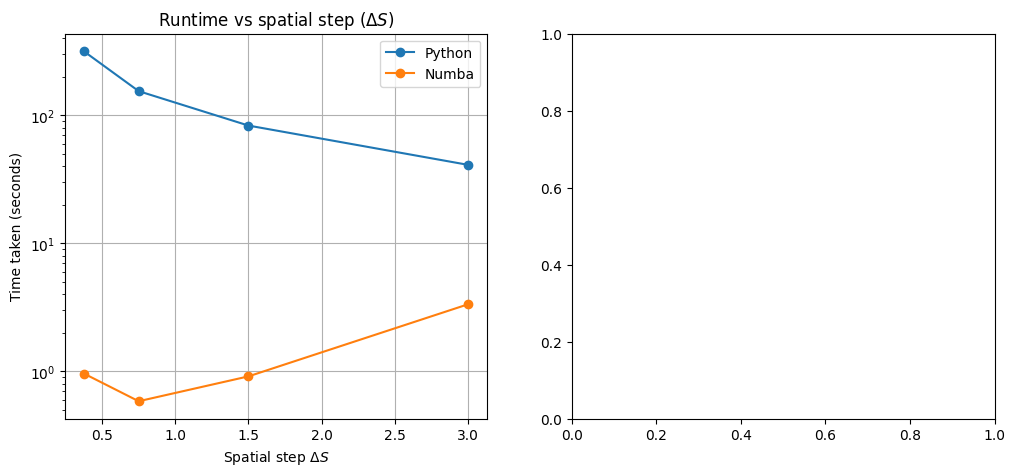

In [3]:

time_taken = np.zeros(7)

S0 = 274.80
K  = 275.00
T  = 0.0548
sigma = 0.1730
r = 0.0375

N = 100000
dS_list = [ 3, 1.5, 0.75, 0.375]

times = []
time_numba = []
prices = []

for dS in dS_list:
    Grid, t, S, tt = bse_exp_call(sigma, r, T, K, N, dS, S0)
    spl = sp.interpolate.CubicSpline(S, Grid[0, :])
    price = float(spl(S0))
    prices.append(price)
    start = time.time()
    Grid, t, S = bse_exp_call_numba(sigma, r, T, K, N, dS, S0)
    end = time.time() - start

    times.append(float(tt))
    time_numba.append(float(end))

Times:  [2.85850041e+10 5.33451560e+10 1.16518953e+11 2.73269999e+11]
Times Numba: [2.05644131e+09 6.81110382e+08 5.68627596e+08 1.13910413e+09]
[3, 1.5, 0.75, 0.375]
4.6212047545501775
[4.61667158 4.62006959 4.62093148 4.62114459]


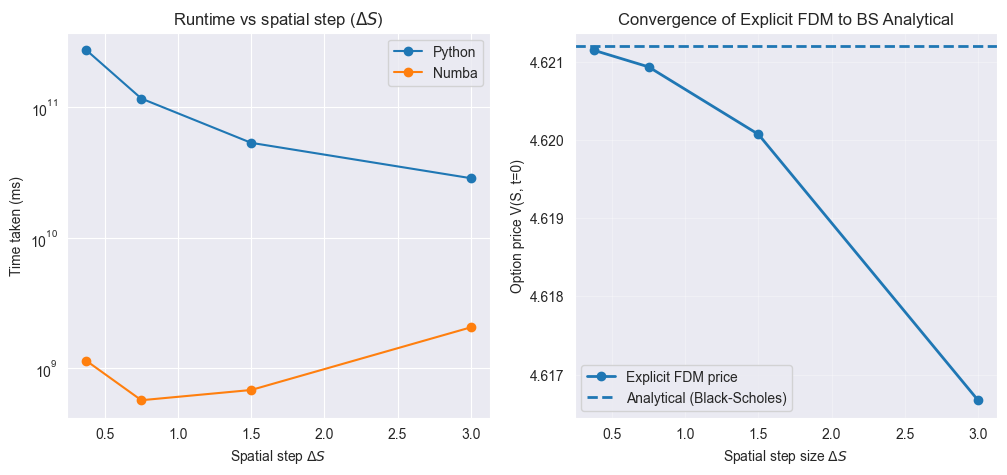

In [8]:

import matplot2tikz

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
times = np.multiply(times,1000)
time_numba = np.multiply(time_numba,1000)
print("Times: ", times)
print("Times Numba:", time_numba)
print(dS_list)
axes[0].plot(dS_list, times, marker="o", label="Python")
axes[0].plot(dS_list, time_numba, marker="o", label="Numba")
axes[0].legend()
axes[0].set_xlabel(r"Spatial step $\Delta S$")
axes[0].set_ylabel("Time taken (ms)")
axes[0].set_title(r"Runtime vs spatial step ($\Delta S$)")
axes[0].set_yscale('log')
axes[0].grid(True)


prices = np.array([4.61667158487682,4.62006959414754, 4.6209314845475,4.62114458687641])
bs = float(bse_analytical(sigma, r, T, K, S0))
print(prices)
errors = prices - bs
abs_errors = np.abs(errors)

axes[1].plot(dS_list, prices, marker="o", linewidth=2, label="Explicit FDM price")
axes[1].axhline(bs, linestyle="--", linewidth=2, label="Analytical (Black-Scholes)")

axes[1].set_xlabel(r"Spatial step size $\Delta S$")
axes[1].set_ylabel("Option price V(S, t=0)")
axes[1].set_title("Convergence of Explicit FDM to BS Analytical")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

matplot2tikz.save("spatialVsTime.tex", encoding="utf-8")


Times:  [12.22200322151184, 25.167358875274658, 51.97419047355652, 104.9567756652832]
Times Numba: [0.03165602684020996, 0.07106304168701172, 0.1868760585784912, 0.3994615077972412]
[3, 1.5, 0.75, 0.375]

[4.61667158 4.62006959 4.62093148 4.62114459]


[,4.65745,4.62448,4.62378, 4.62168]

[ 193.666  189.912 215.09 289.426]





Times:  [287078. 290095. 290604. 287748.]
Times Numba: [193666. 189912. 215090. 289426.]
[3, 1.5, 0.75, 0.375]
[4.61667158 4.62006959 4.62093148 4.62114459]


NameError: name 'matplot2tikz' is not defined

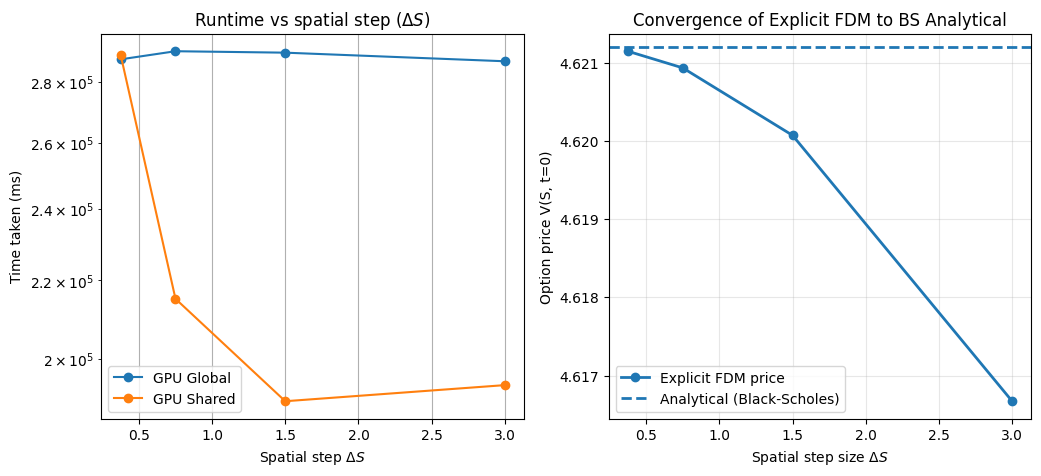

In [4]:
times = [287.078, 290.095, 290.604, 287.748]
time_numba = [193.666, 189.912, 215.09, 289.426]
dS_list = [3, 1.5, 0.75, 0.375]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
times = np.multiply(times, 1000)
time_numba = np.multiply(time_numba, 1000)
print("Times: ", times)
print("Times Numba:", time_numba)
print(dS_list)
axes[0].plot(dS_list, times, marker="o", label="GPU Global")
axes[0].plot(dS_list, time_numba, marker="o", label="GPU Shared")
axes[0].legend()
axes[0].set_xlabel(r"Spatial step $\Delta S$")
axes[0].set_ylabel("Time taken (ms)")
axes[0].set_title(r"Runtime vs spatial step ($\Delta S$)")
axes[0].set_yscale('log')
axes[0].grid(True)

prices = np.array([4.61667158, 4.62006959, 4.62093148, 4.62114459])
bs = float(4.6212047545501775)
print(prices)

axes[1].plot(dS_list, prices, marker="o", linewidth=2, label="Explicit FDM price")
axes[1].axhline(bs, linestyle="--", linewidth=2, label="Analytical (Black-Scholes)")

axes[1].set_xlabel(r"Spatial step size $\Delta S$")
axes[1].set_ylabel("Option price V(S, t=0)")
axes[1].set_title("Convergence of Explicit FDM to BS Analytical")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
matplot2tikz.save("spatialVsTimeGPU.tex", encoding="utf-8")

Times:  [2.85850041e+13 5.33451560e+13 1.16518953e+14 2.73269999e+14]
Times Numba: [2.05644131e+12 6.81110382e+11 5.68627596e+11 1.13910413e+12]
[3, 1.5, 0.75, 0.375]
[4.61667158 4.62006959 4.62093148 4.62114459]


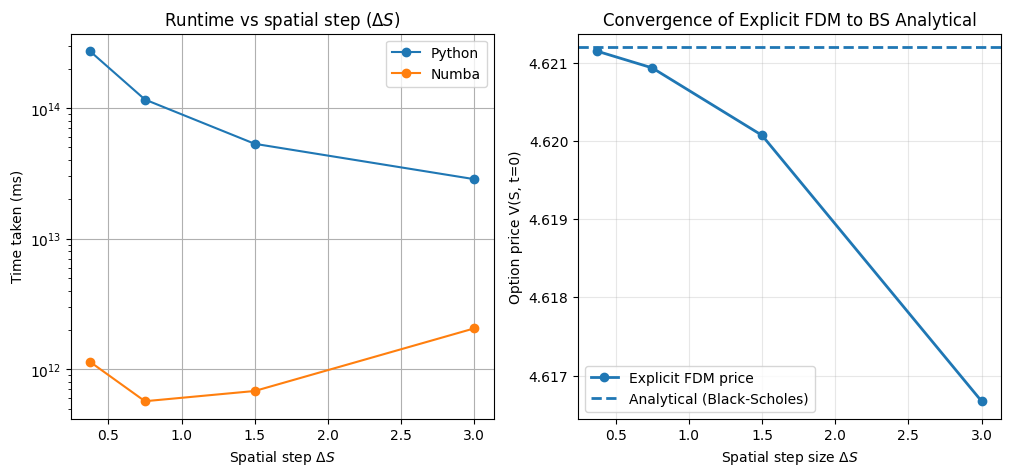

In [7]:
gpu_main()